In [1]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
news_cols = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities']
news_df = pd.read_csv('../data/MINDsmall_train/news.tsv', sep='\t', names=news_cols)

behavior_cols = ['impression_id', 'user_id', 'time', 'history', 'impressions']
behaviors_df = pd.read_csv('../data/MINDsmall_train/behaviors.tsv', sep='\t', names=behavior_cols)

In [3]:
print("Basic Statistics:\n")

num_users = behaviors_df["user_id"].nunique()
num_articles = news_df["news_id"].nunique()
num_impressions = len(behaviors_df)

expanded_behaviors = behaviors_df[['user_id', 'impressions']].copy()
expanded_behaviors['impressions'] = expanded_behaviors['impressions'].str.split(' ')
expanded_behaviors = expanded_behaviors.explode('impressions').dropna()

temp_split = expanded_behaviors['impressions'].str.split('-', expand=True)
expanded_behaviors['news_id'] = temp_split[0]
expanded_behaviors['label'] = pd.to_numeric(temp_split[1], errors='coerce')

expanded_behaviors = expanded_behaviors.dropna(subset=['label'])
expanded_behaviors['label'] = expanded_behaviors['label'].astype(int)

total_clicks = expanded_behaviors['label'].sum()
total_impressions = len(expanded_behaviors)
ctr = total_clicks / total_impressions

print(f"Users: {num_users}")
print(f"Articles: {num_articles}")
print(f"Total Impressions: {num_impressions}")
print(f"Total Clicks: {total_clicks}")
print(f"Overall CTR: {ctr:.4f}")

merged_df = expanded_behaviors.merge(news_df[['news_id', 'category']], on='news_id', how='left')
category_stats = merged_df.groupby('category')['label'].agg(['sum', 'count'])
category_stats.columns = ['clicks', 'impressions']
category_stats['CTR'] = category_stats['clicks'] / category_stats['impressions']
print("\nCTR per Category:\n", category_stats.sort_values('CTR', ascending=False))

Basic Statistics:

Users: 50000
Articles: 51282
Total Impressions: 156965
Total Clicks: 236344
Overall CTR: 0.0404

CTR per Category:
                clicks  impressions       CTR
category                                    
music           15988       269008  0.059433
tv              14544       246462  0.059011
weather          4582        88646  0.051689
sports          28181       592226  0.047585
video            4262        93744  0.045464
news            69408      1591038  0.043624
lifestyle       26584       655440  0.040559
finance         20597       564671  0.036476
health          10863       304088  0.035723
northamerica        1           29  0.034483
movies           4186       132091  0.031690
entertainment   10530       349930  0.030092
foodanddrink    10883       369382  0.029463
autos            7428       271426  0.027367
travel           8304       315101  0.026353
kids                3          162  0.018519


Category Distribution:



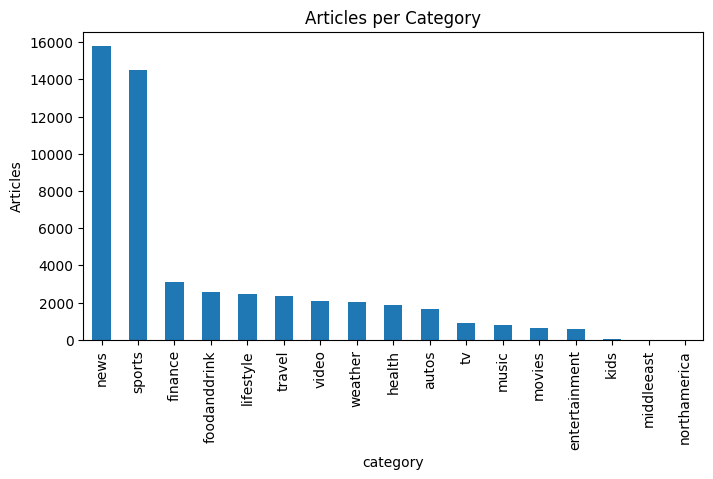

News and sports make up the majority of the articles with a steep decline after.



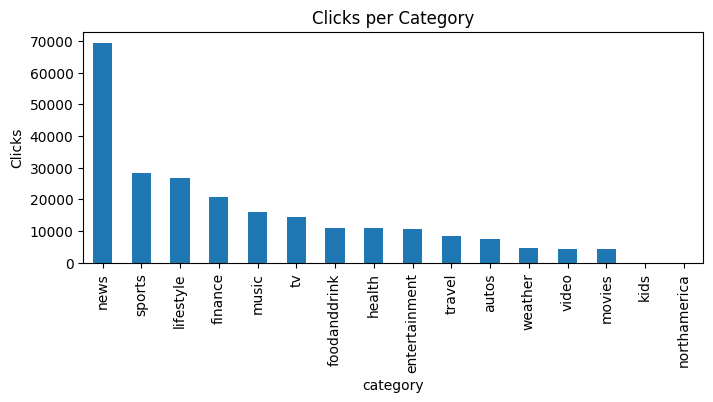

News makes up the majority of the clicks and sports is far off despite being close in number of articles.

Dominant Categories: category
news         69408
sports       28181
lifestyle    26584
Name: clicks, dtype: int64
Underrepresented Categories: category
northamerica       1
kids               3
movies          4186
Name: clicks, dtype: int64


In [4]:
print("Category Distribution:\n")

plt.figure(figsize=(8, 4))
news_df['category'].value_counts().plot(kind='bar')
plt.title('Articles per Category')
plt.ylabel('Articles')
plt.show()

print("News and sports make up the majority of the articles with a steep decline after.\n")

plt.figure(figsize=(8, 3))
category_stats['clicks'].sort_values(ascending=False).plot(kind='bar')
plt.title('Clicks per Category')
plt.ylabel('Clicks')
plt.show()

print("News makes up the majority of the clicks and sports is far off despite being close in number of articles.\n")

print("Dominant Categories:", category_stats['clicks'].nlargest(3))
print("Underrepresented Categories:", category_stats['clicks'].nsmallest(3))

User Activity Distribution:



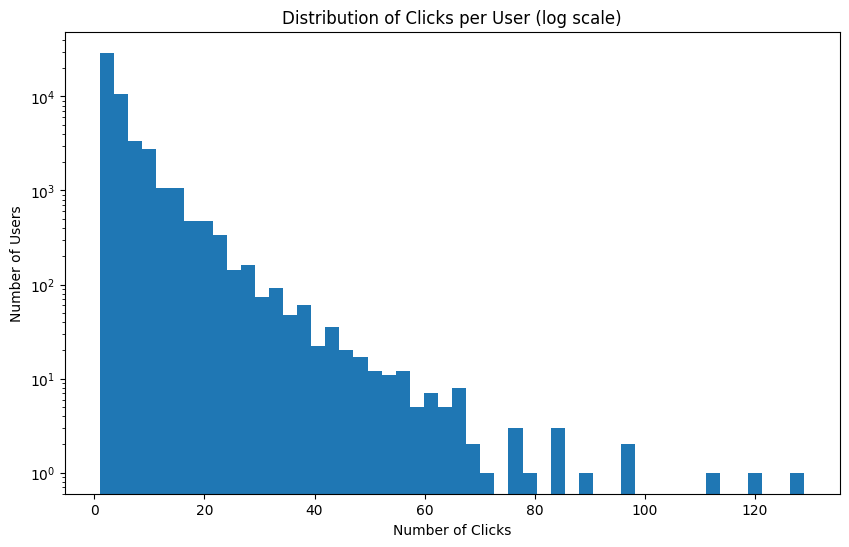

Majority of all users have less than 10~20 clicks, with the bins of 60+ clicks having less than 10 users.

Percentage of users with fewer than 10 clicks: 88.3280

The power-law behavior is indicated by the long tail in the log-scale histogram.


In [5]:
print(f"User Activity Distribution:\n")

user_clicks = expanded_behaviors.groupby('user_id')['label'].sum()

plt.figure(figsize=(10, 6))
plt.hist(user_clicks, bins=50, log=True)
plt.title('Distribution of Clicks per User (log scale)')
plt.xlabel('Number of Clicks')
plt.ylabel('Number of Users')
plt.show()

print("Majority of all users have less than 10~20 clicks, with the bins of 60+ clicks having less than 10 users.\n")

less_than_10 = (user_clicks < 10).mean() * 100

print(f"Percentage of users with fewer than 10 clicks: {less_than_10:0.4f}\n")
print("The power-law behavior is indicated by the long tail in the log-scale histogram.")

History Length Analysis:

Mean history length: 32.54
Median history length: 19.00
90th percentile: 78.00


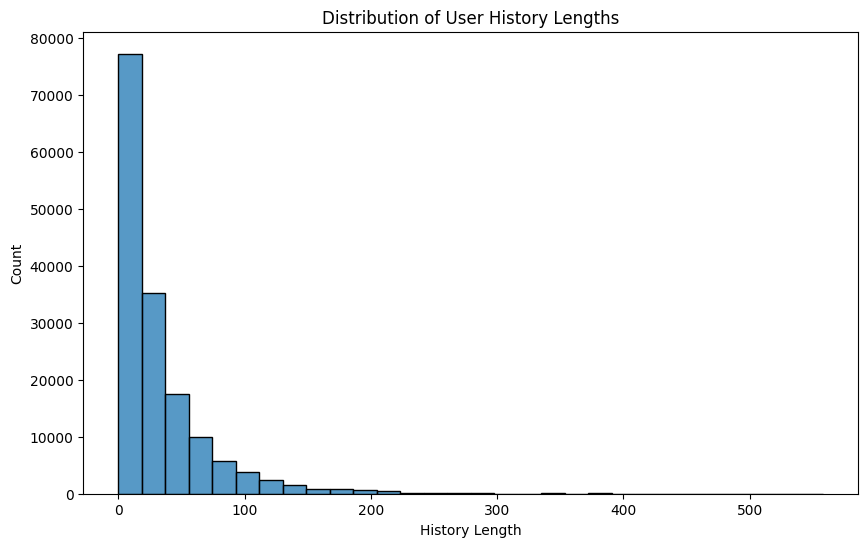

In [6]:
print("History Length Analysis:\n")

behaviors_df['history_len'] = behaviors_df['history'].apply(lambda x: len(x.split()) if pd.notna(x) else 0)

print(f"Mean history length: {behaviors_df['history_len'].mean():.2f}")
print(f"Median history length: {behaviors_df['history_len'].median():.2f}")
print(f"90th percentile: {behaviors_df['history_len'].quantile(0.9):.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(behaviors_df['history_len'], bins=30, kde=False)
plt.title('Distribution of User History Lengths')
plt.xlabel('History Length')
plt.show()

In [7]:
print("Impression Size Analysis\n")

behaviors_df['impression_size'] = behaviors_df['impressions'].apply(lambda x: len(x.split(" ")))
mean_impression_size = behaviors_df['impression_size'].mean()
print(f"Average candidates per impression: {mean_impression_size:.2f}")
print(f"Fraction of shown articles clicked: {ctr:.4f}")

Impression Size Analysis

Average candidates per impression: 37.23
Fraction of shown articles clicked: 0.0404


Temporal Patterns



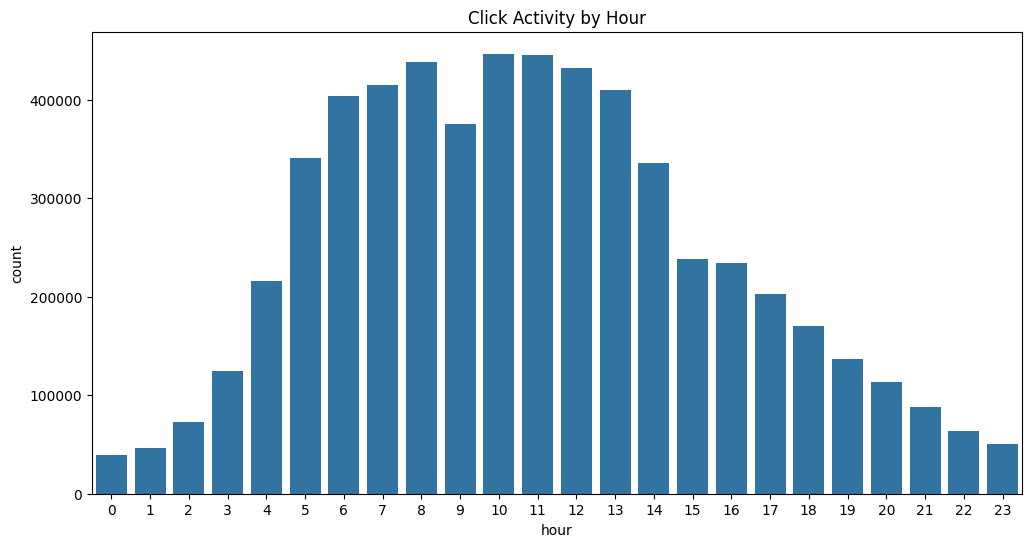

Activity seems to increase quickly in the morning, peaking around 10-11, then slowly declining throughout the day.


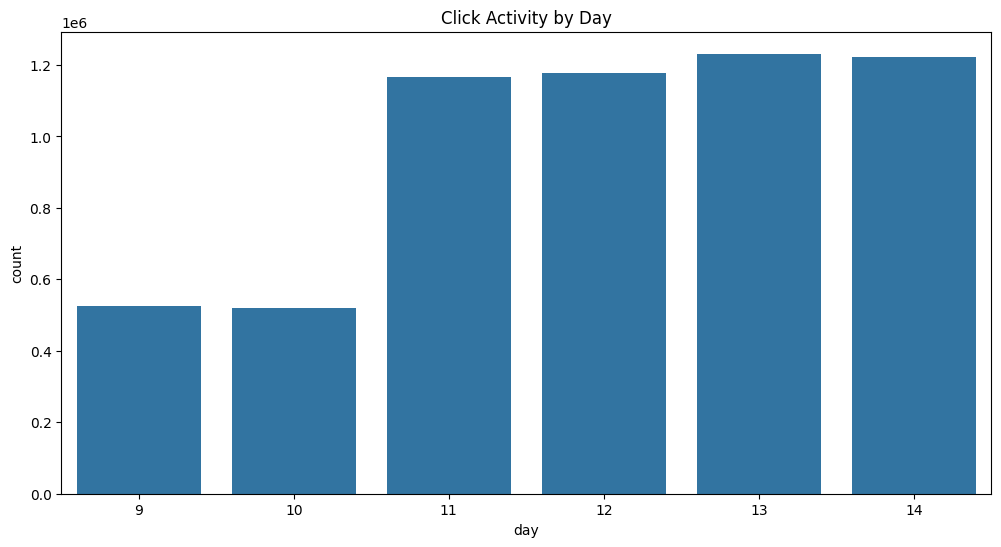

The dates are 11/9/2019 through 11/14/2019 with 11/9 being a Saturday and 11/14 being a Thursday. Activity is lowest during the weekend but picks up during the week.


In [8]:
print("Temporal Patterns\n")

behaviors_df['date'] = pd.to_datetime(behaviors_df['time'], format='%m/%d/%Y %I:%M:%S %p')
behaviors_df['hour'] = behaviors_df['date'].dt.hour
behaviors_df['day'] = behaviors_df['date'].dt.day

plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=expanded_behaviors.merge(behaviors_df, left_index=True, right_index=True, how='left'))
plt.title("Click Activity by Hour")
plt.show()

print("Activity seems to increase quickly in the morning, peaking around 10-11, then slowly declining throughout the day.")

plt.figure(figsize=(12, 6))
sns.countplot(x='day', data=expanded_behaviors.merge(behaviors_df, left_index=True, right_index=True, how='left'))
plt.title("Click Activity by Day")
plt.show()

print("The dates are 11/9/2019 through 11/14/2019 with 11/9 being a Saturday and 11/14 being a Thursday. Activity is lowest during the weekend but picks up during the week.") 

Text Statistics



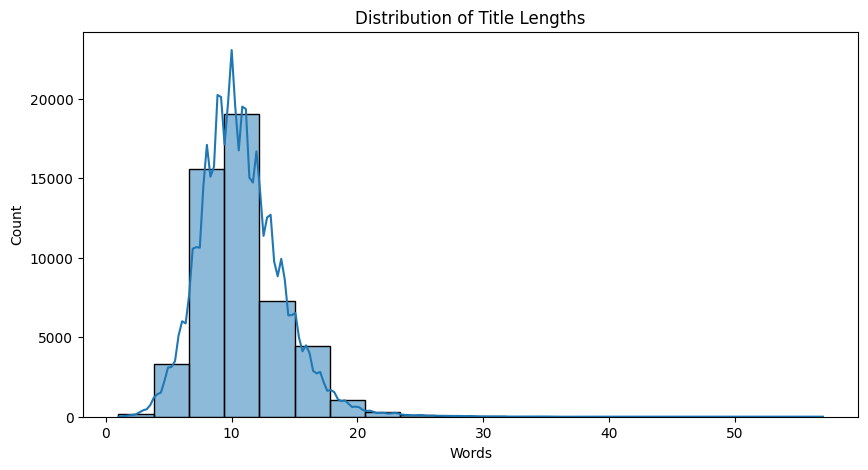

Most articles have around 10 words for their title with the lowest having 1 and the highest having 57.


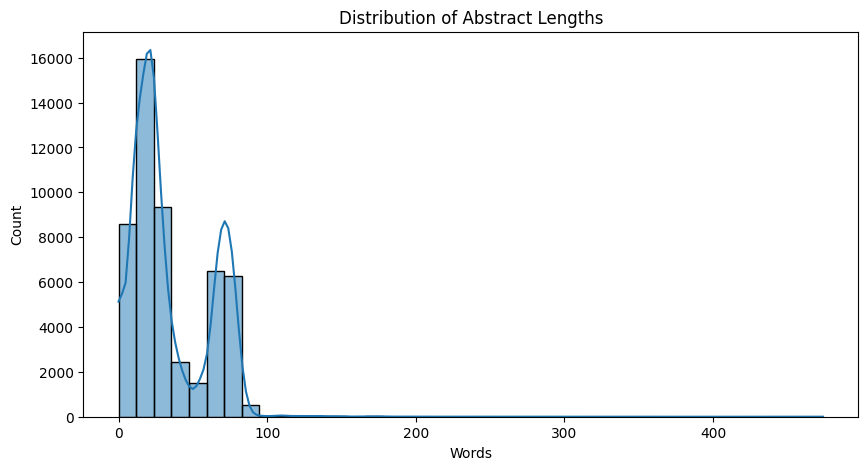

There are two peaks with one at around 25 words and the other at around 75 words. The shortest abstract is 0 words and the longest is 474 words.


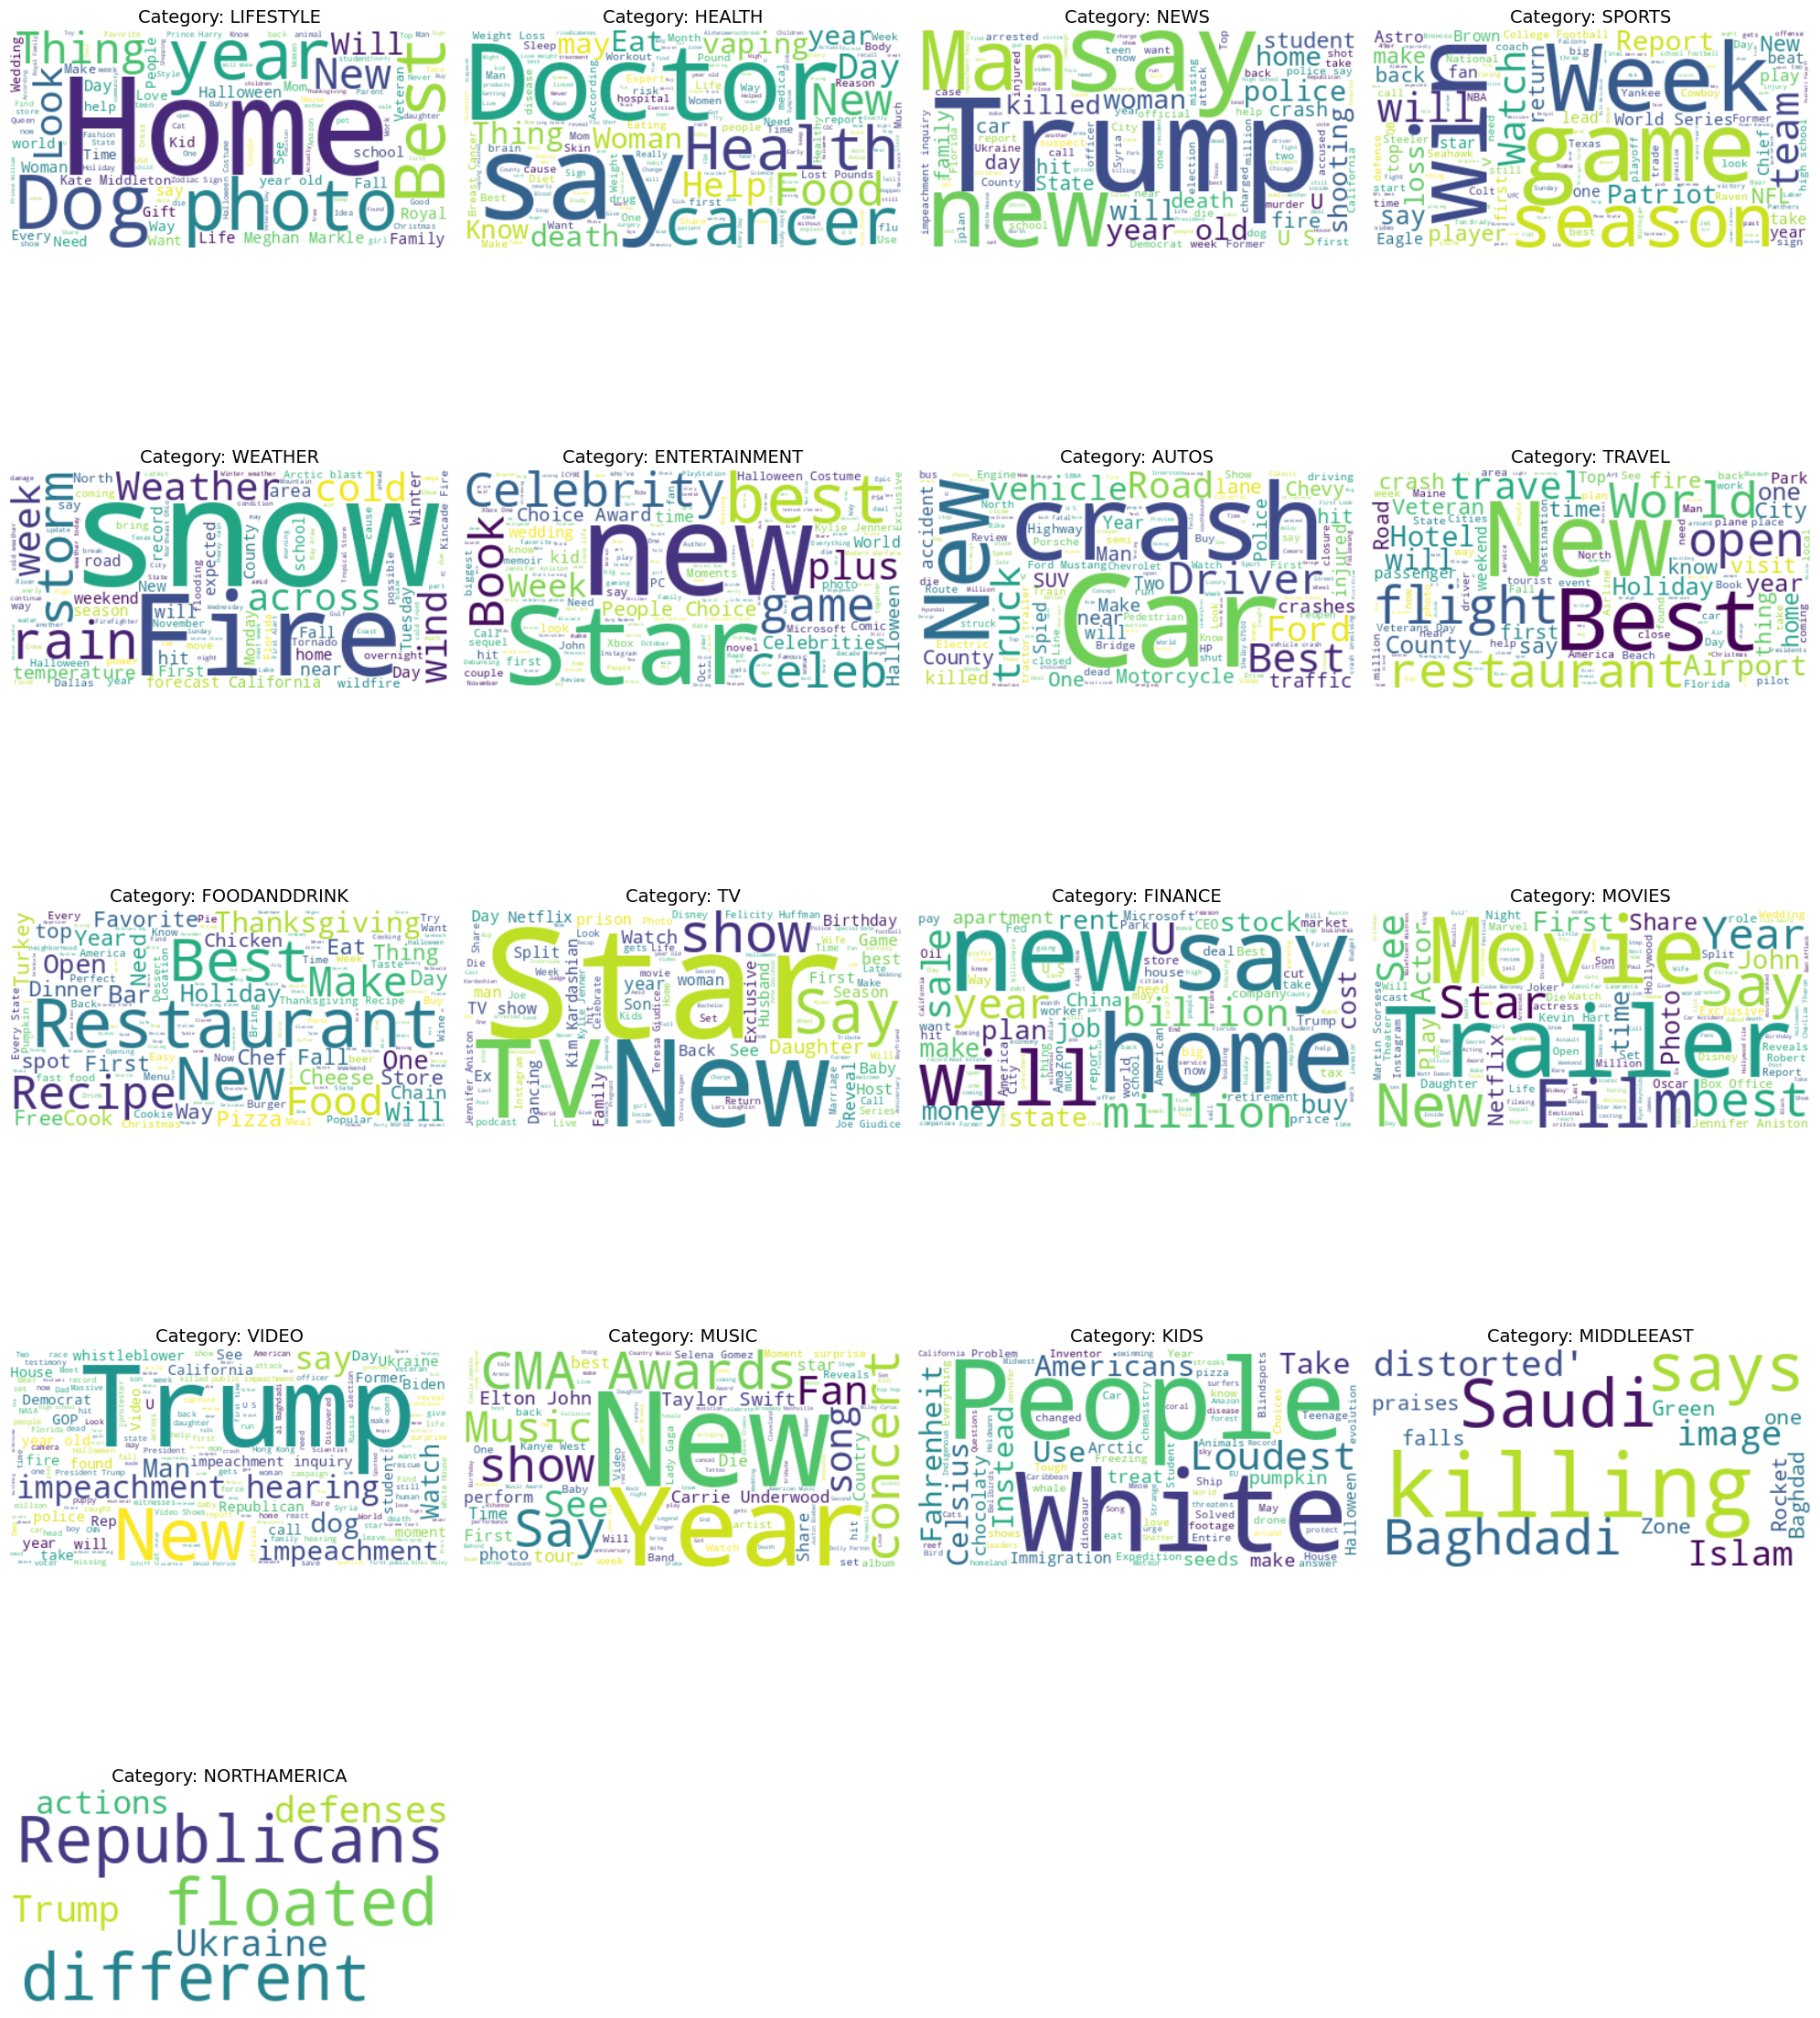

In [9]:
print("Text Statistics\n")

news_df['title_len'] = news_df['title'].apply(lambda x: len(x.split()))
news_df['abstract_len'] = news_df['abstract'].apply(lambda x: len(x.split()) if pd.notna(x) else 0)


plt.figure(figsize=(10, 5))
sns.histplot(news_df['title_len'], bins=20, kde=True)
plt.title("Distribution of Title Lengths")
plt.xlabel("Words")
plt.show()

print(f"Most articles have around 10 words for their title with the lowest having {news_df['title_len'].min()} and the highest having {news_df['title_len'].max()}.")

plt.figure(figsize=(10, 5))
sns.histplot(news_df['abstract_len'], bins=40, kde=True)
plt.title("Distribution of Abstract Lengths")
plt.xlabel("Words")
plt.show()

print(f"There are two peaks with one at around 25 words and the other at around 75 words. The shortest abstract is {news_df['abstract_len'].min()} words and the longest is {news_df['abstract_len'].max()} words.")

categories = news_df['category'].unique()

cols = 4
rows = math.ceil(len(categories) / cols)

plt.figure(figsize=(20, rows * 5))

for i, cat in enumerate(categories):
    cat_titles = ' '.join(news_df[news_df['category'] == cat]['title'].dropna())
    
    if cat_titles:
        wordcloud = WordCloud(width=400, height=200, background_color='white').generate(cat_titles)
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Category: {cat.upper()}', fontsize=14)
        plt.axis('off')

plt.tight_layout()
plt.show()